<h1>Finding the Relevancy of Contextual Data in terms of Online Shopper Purchasing Intentions</h1>
<h4> Theo Scola <br>
CSC-321 Final </h4>

<h2> 1. Abstract </h2>
<h4> Machine Learning can be very helpful when predicting consumer practices in e-commerce. However, irrelevant data within datasets can harm model efficiency and degrade prediction performance. Using an Online Shoppers Purchasing Intentions dataset, we look to see the effect of contextual data on predicting revenue. We use feature selection techniques to find the most important contextual elements of the dataset, then use linear models to compare prediction accuracy. We find that the contextual data does not help with predicitons and is mostly irrelevant.

<h2> 2. Introduction </h2>
<h4> Due to the importance of online shopping in the modern economy, it is important to look at what factors make online shoppers more likely to purchase something. This has become a focus of a multitude of researchers and businesses, and the main way to continue to learn and adapt to the changing market is through utilizing machine learning. ML and data mining gives organizations a way to look at the different kinds of factors that affect how shoppers act on webpages and draw meaningful insights from them. When looking at the data of online shoppers we are met with two main categories of data, those being Website Related/Behavioral data and Non Website Related/Contextual data. The behavioral data relates to the website-user interaction showing us what pages the user is looking at and if they are staying on the page, interacting with the page, or leaving the page. The contextual data relates to things unrelated to the website like what browser the user is on, or what time of year it is. <br> Our investigation of this data is to look at the importance of this contextual data: Does including contextual data within our predictions lead to better or worse outcomes? What parts of the contextual data is the most important for predictions? <br>
We can do this by creating ML models using different combinations of data. In our case we will be using two different models, one using only the behavioral data, and the other using both behavioral and contextual data. Both models look to classify the user sessions as either 'generating revenue' or not.


<h2> 3. Motivation </h2>
<h4>The reason to look at the contextual data is to see the importance of including it in future predictions. Including contextual data already has a number of drawbacks for machine learning. By including more data, we are increasing dimensionality and complexity of our models, making them less understandable and potentially degrading their performance. Additionally, using more data leads to slower computing times for the models which leads to increased costs for organizations using them. Finally, having models that use contextual data for predictions also means that contextual data has to be gathered in the first place to create new predictions. Thus through this study we will find the usefulness of the contextual data, so that further ML predictions on similar data don't run into potential losses through inefficiency.

<h2> 4. Data </h2> <h4>
Dataset Information

* 12,300 Instances
* 17 Features
* No Missing Values

The data is available on the UCI machine learning repository. It is the Online Shoppers Purchasing Intentions Dataset. The class value is revenue, seeing if revenue was made in the sesssion or not. The data is very imbalanced with 84.5% (10,422) resulting in no revenue.
The data includes both contextual and behavioral data.

Behavioral Features:

* Administrative
* Administrative_Duration
* Informational
* Informational_Duration
* ProductRelated
* ProductRelated_Duration
* BounceRates
* ExitRates
* PageValues

Administrative, Informational, and ProductRelated is the type of webpage visited in the session. Duration is how long the user spent on that website. Then BounceRates, ExitRates, and PageValues are google analytic values for the user's interactions connected to leaving the page or buying something.

Contextual Features:

* SpecialDay
*	Month
*	OperatingSystems
*	Browser
*	Region
*	TrafficType
*	VisitorType
*	Weekend

SpecialDay gives the proximity of a holiday/special shopping day. TrafficType is shows how the user got to the website (searched, clicked on a link). VisitorType classifies whether a user is a new visitor, a returning one, or other.


 In terms of noise, the majority of the 'Duration' attributes have noise due to the majority of them being zero due to the user not going onto a page within that category, so if a user does go onto a website in that category, then they will already be an outlier.

In [ ]:
import pandas as pd

labels = ['Administrative','Administrative_Duration','Informational','Informational_Duration','ProductRelated','ProductRelated_Duration','BounceRates','ExitRates','PageValues','SpecialDay', 'Month','OperatingSystems','Browser','Region','TrafficType','VisitorType','Weekend', 'Revenue']

purchasing_intentions = pd.read_csv('https://raw.githubusercontent.com/tscola24/ML-Final-Data/refs/heads/main/online_shoppers_intention.csv')

purchasing_intentions.describe()


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,2.124006,2.357097,3.147364,4.069586
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,0.911325,1.717277,2.401591,4.025169
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


In [ ]:
purchasing_intentions.head()


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


<h2>5. Experiments </h2>

<h3> 5.1. Operating Systems and Browsers </h3>
<h4>
To see how user's different operating systems and browsers affect revenue, we use a correlation heat-map to see correlation between each OS/browser and the revenue.

In [ ]:
temp_df = purchasing_intentions.drop(labels[0:11], axis=1)
temp_df = temp_df.drop(labels[13:-1], axis=1)

temp_df = pd.get_dummies(temp_df, columns=['Browser'], prefix_sep='_', drop_first=False)
temp_df = pd.get_dummies(temp_df, columns=['OperatingSystems'], prefix_sep='_', drop_first=False)

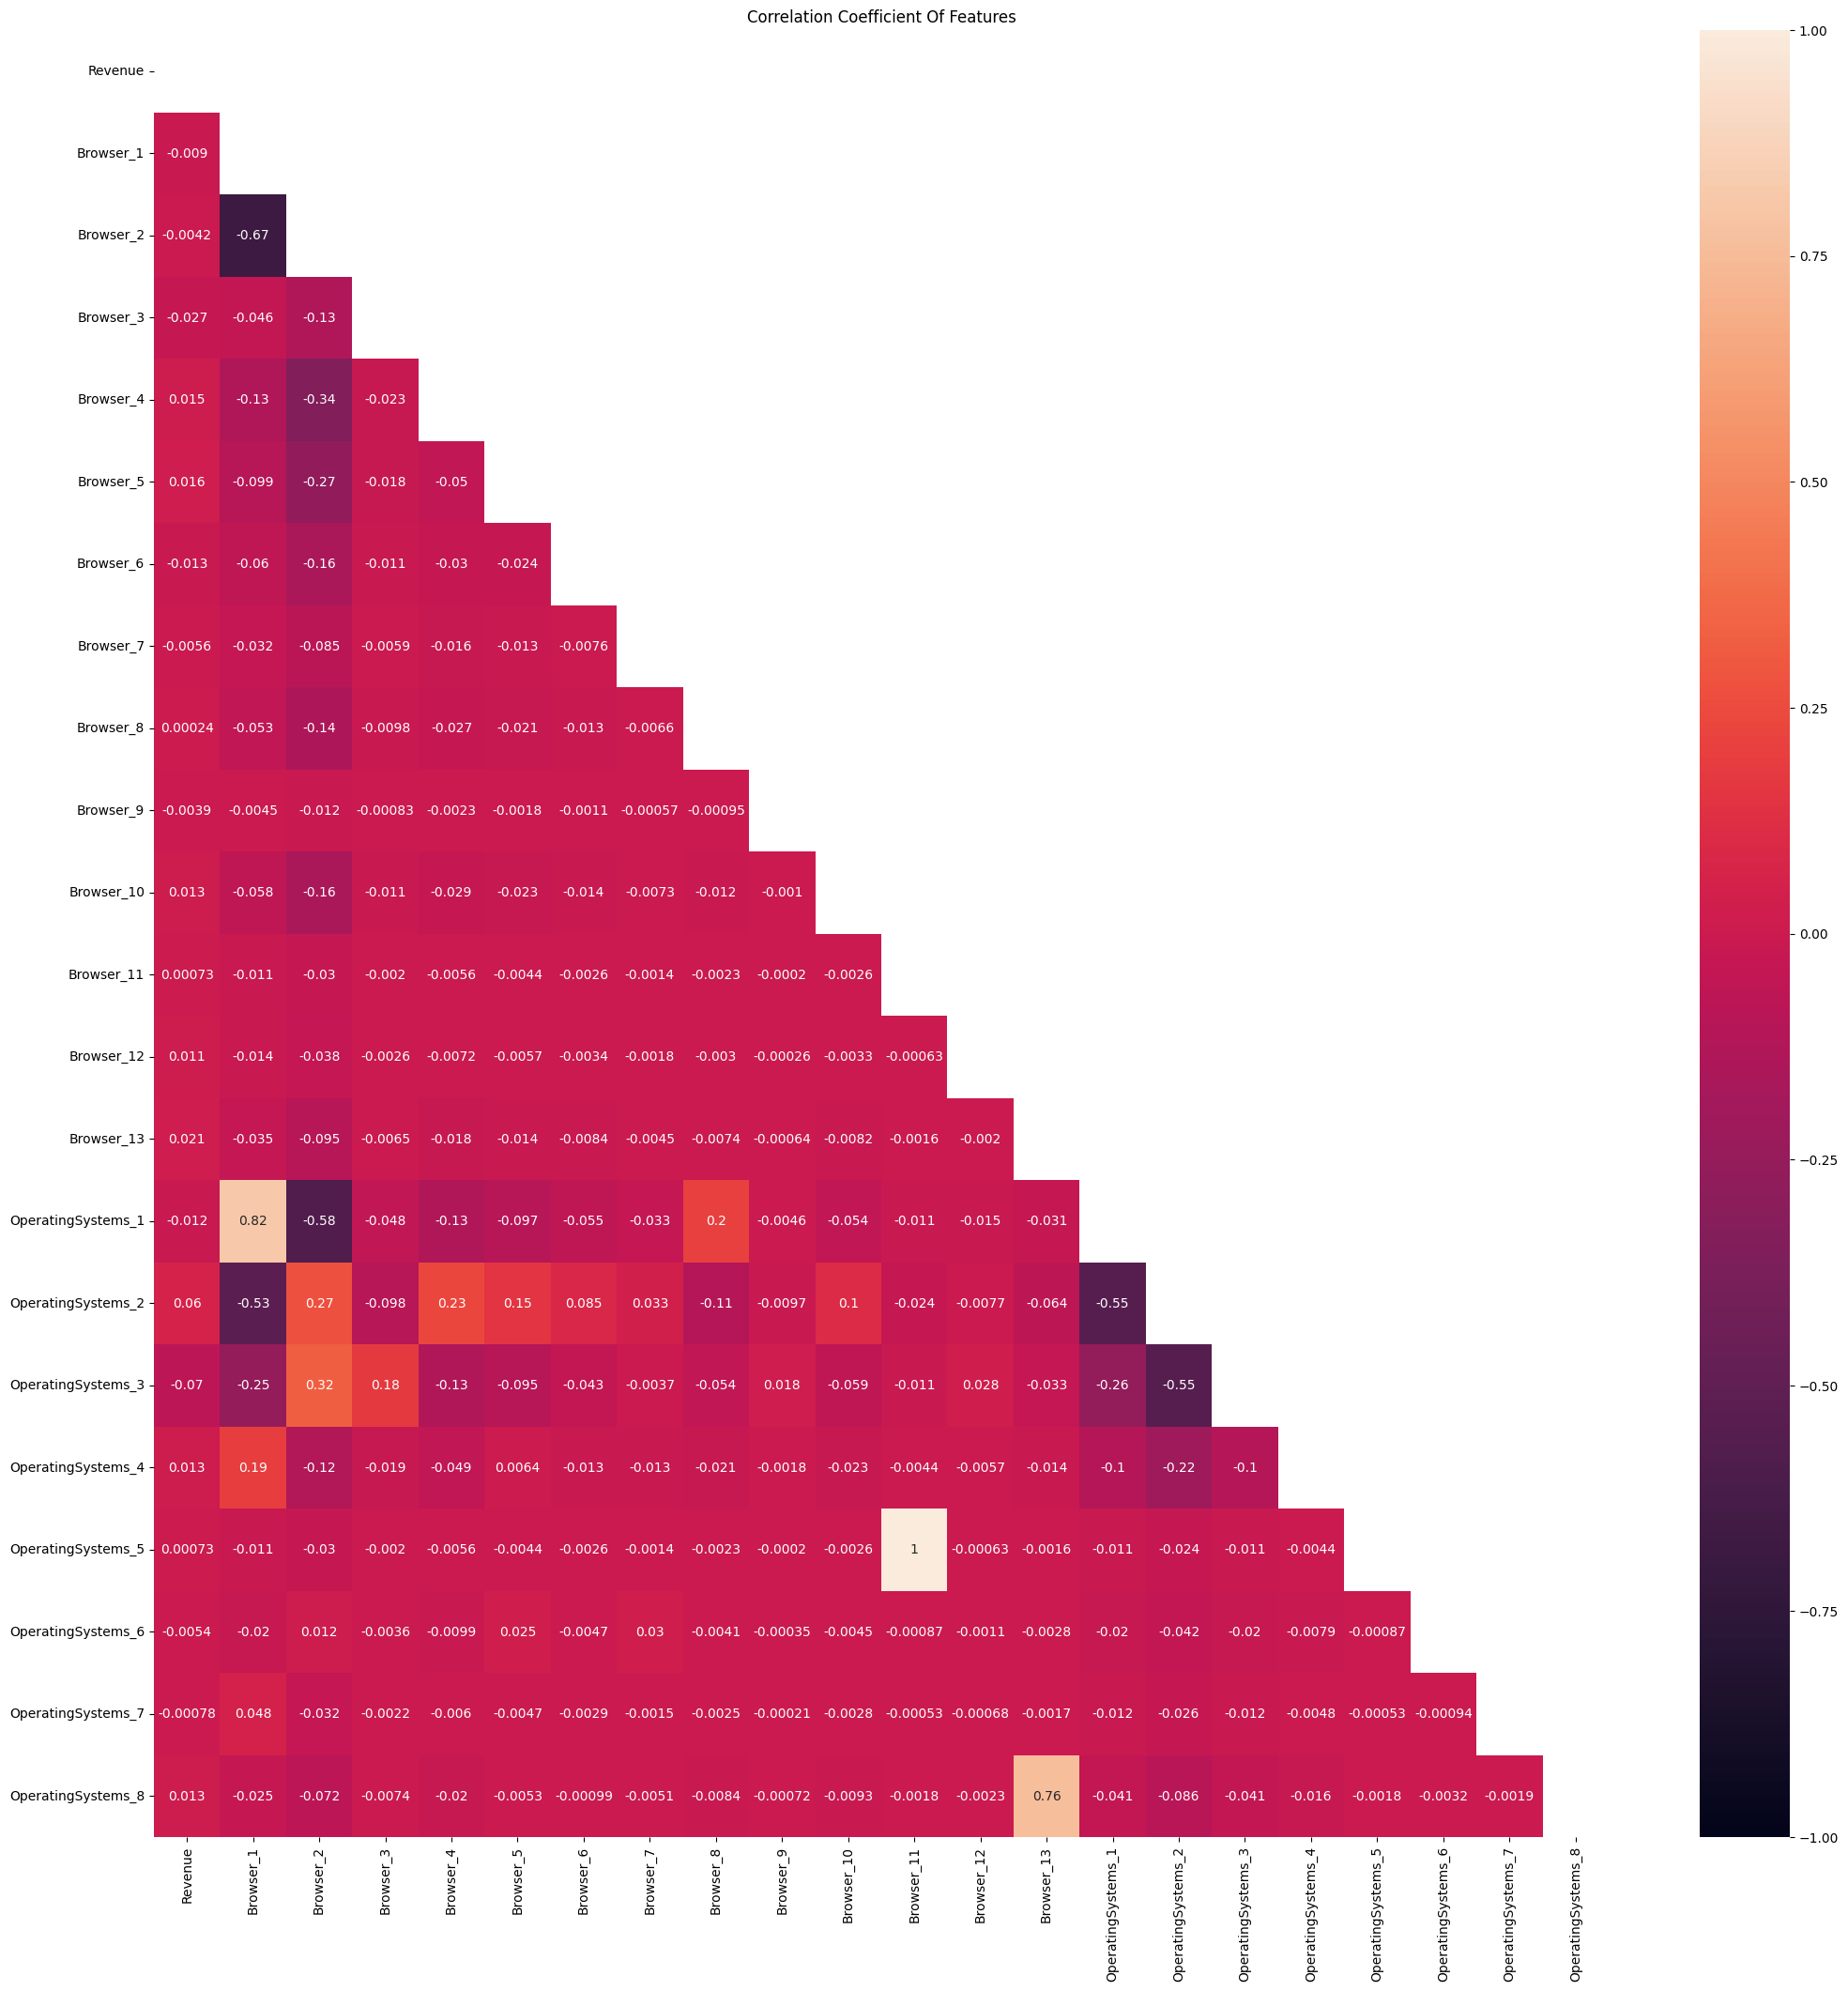

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

tmp = temp_df.select_dtypes(include=['number','bool'])

plt.figure(figsize=(25,25))
mask = np.triu(np.ones_like(tmp.corr(), dtype=bool))


sns.heatmap(tmp.corr(), annot=True, mask=mask, vmin=-1, vmax=1)
plt.title('Correlation Coefficient Of Features')
plt.show()

<h4>As seen above in the heat map, there are no significant factors within OS or browser that affect revenue.

<h3>5.2. Visitor Types </h3>
<h4>To determine which types of visitors affect revenue and if returning visitors are more likely to correlate to revenue than other visitors, we use a correlation heat map.

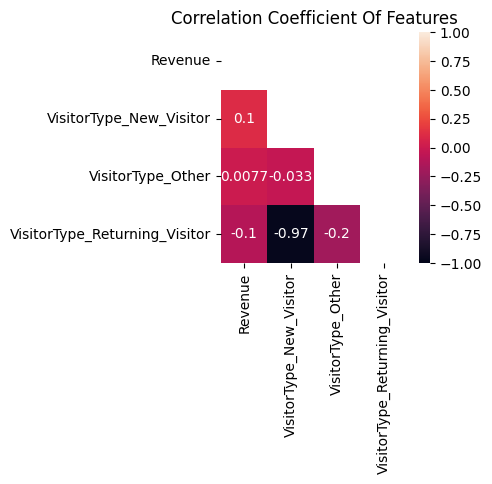

In [ ]:
temp_df2 = purchasing_intentions.drop(labels[0:15], axis=1)
temp_df2 = temp_df2.drop(labels[16], axis=1)
temp_df2 = pd.get_dummies(temp_df2, columns=['VisitorType'], prefix_sep='_', drop_first=False)

tmp = temp_df2.select_dtypes(include=['number','bool'])

plt.figure(figsize=(3,3))
mask = np.triu(np.ones_like(tmp.corr(), dtype=bool))


sns.heatmap(tmp.corr(), annot=True, mask=mask, vmin=-1, vmax=1)
plt.title('Correlation Coefficient Of Features')
plt.show()

<h4>From this heatmap, we can see that new visitors (slightly) more likely to generate revenue than returning or other visitor types.

<h3>5.3. Date of browsing </h3>
<h4>To see how different dates affect how the revenue, I am going to use another heatmap to see how months, proximity to a 'special day', and the weekend correlate to revenue.

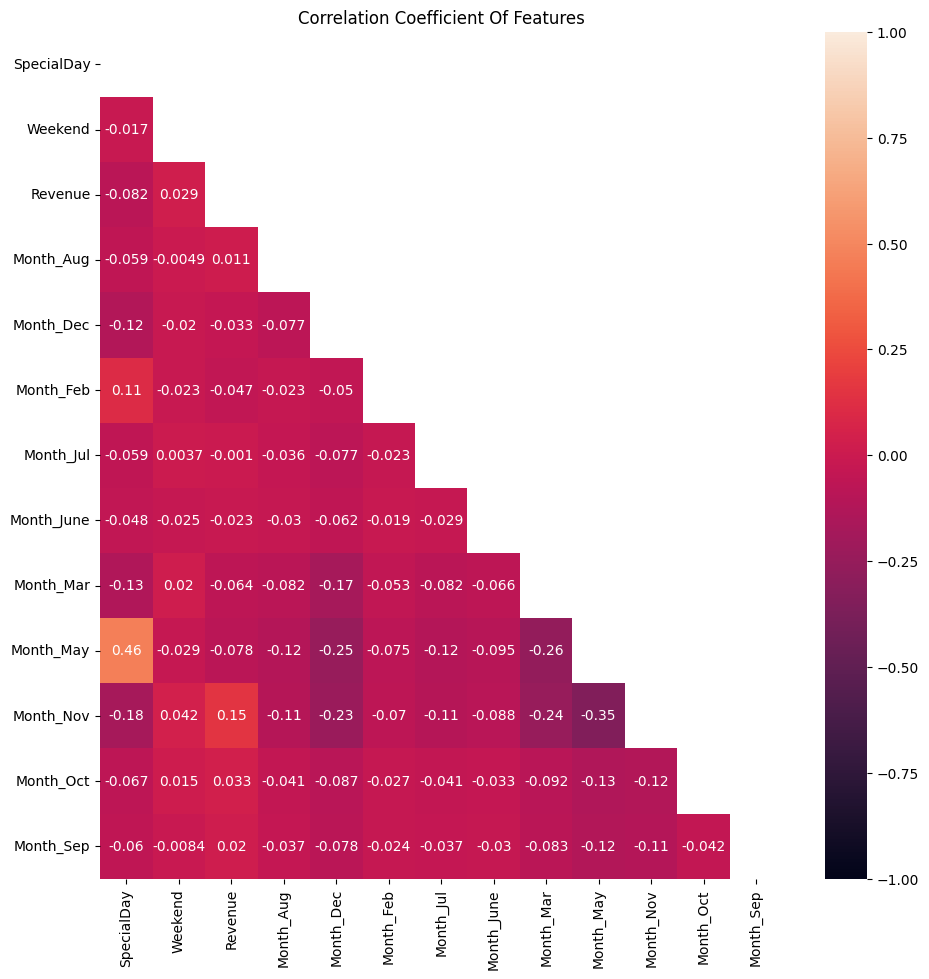

In [ ]:
temp_df3 = purchasing_intentions.drop(labels[0:9], axis=1)
temp_df3 = temp_df3.drop(labels[11:16], axis=1)
temp_df3 = pd.get_dummies(temp_df3, columns=['Month'], prefix_sep='_', drop_first=False)

tmp = temp_df3.select_dtypes(include=['number','bool'])

plt.figure(figsize=(11,11))
mask = np.triu(np.ones_like(tmp.corr(), dtype=bool))


sns.heatmap(tmp.corr(), annot=True, mask=mask, vmin=-1, vmax=1)
plt.title('Correlation Coefficient Of Features')
plt.show()

<h4>While the proximity to a special day has no effect on the revenue, one important takeaway here is the correlation of November and Revenue. The positive correlation here is most likely related to black friday / cyber monday.

<h3>5.4. Regions </h3>
<h4>To check whether regions matter in terms of predicting revenue we apply another correlation heat map.

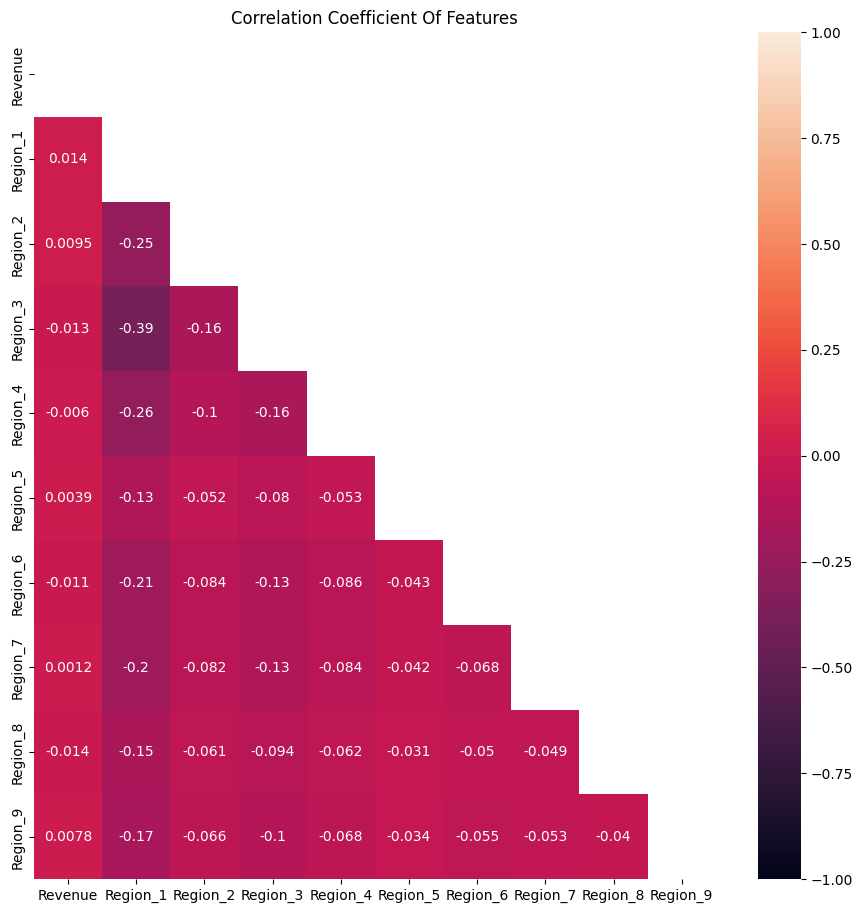

In [ ]:
temp_df4 = purchasing_intentions.drop(labels[0:13], axis=1)
temp_df4 = temp_df4.drop(labels[14:17], axis=1)
temp_df4 = pd.get_dummies(temp_df4, columns=['Region'], prefix_sep='_', drop_first=False)

tmp = temp_df4.select_dtypes(include=['number','bool'])

plt.figure(figsize=(11,11))
mask = np.triu(np.ones_like(tmp.corr(), dtype=bool))


sns.heatmap(tmp.corr(), annot=True, mask=mask, vmin=-1, vmax=1)
plt.title('Correlation Coefficient Of Features')
plt.show()

<h4>As seen above, regions have no effect on the revenue.

<h3>5.5. Feature Selection </h3>
<h4> After performing the above experiments, it is time to apply those changes to our datasets to both remove and discretize our contextual data.

In [ ]:
partial_reduced_purchasing_intentions = purchasing_intentions.drop(labels[9:14], axis=1)
partial_reduced_purchasing_intentions.drop(labels='Weekend', axis='columns', inplace=True)
partial_reduced_purchasing_intentions = partial_reduced_purchasing_intentions.assign(In_Nov = temp_df3['Month_Nov'])
partial_reduced_purchasing_intentions = pd.get_dummies(partial_reduced_purchasing_intentions, columns=['VisitorType'], prefix_sep='_', drop_first=False)
partial_reduced_purchasing_intentions.drop(labels='VisitorType_Other', axis='columns', inplace=True)
partial_reduced_purchasing_intentions.drop(labels='Revenue', axis='columns', inplace=True)
partial_reduced_purchasing_intentions = partial_reduced_purchasing_intentions.assign(Revenue = purchasing_intentions['Revenue'])

labels_to_be_scaled = ['In_Nov', 	'VisitorType_New_Visitor', 	'VisitorType_Returning_Visitor', 	'Revenue']

partial_reduced_labels = ['Administrative','Administrative_Duration','Informational','Informational_Duration','ProductRelated','ProductRelated_Duration','BounceRates','ExitRates','PageValues','TrafficType', 'In_Nov','VisitorType_New_Visitor', 	'VisitorType_Returning_Visitor','Revenue']

from sklearn import preprocessing

for label in labels_to_be_scaled:
  le = preprocessing.LabelEncoder()
  vals = partial_reduced_purchasing_intentions[label].values
  le.fit(vals)
  partial_reduced_purchasing_intentions[label] = le.transform(vals)



<h4>Additionally, we will be comparing this algorithm with one without contextual data to see if the algorithm with the contextual data can have better predictions. So we will setup a second dataset for another linear algorithm to run on.

In [ ]:
reduced_purchasing_intentions = purchasing_intentions.drop(labels[9:17], axis=1)
le = preprocessing.LabelEncoder()
val = reduced_purchasing_intentions['Revenue'].values
le.fit(val)
reduced_purchasing_intentions["Revenue"] = le.transform(val)

reduced_labels = ['Administrative','Administrative_Duration','Informational','Informational_Duration','ProductRelated','ProductRelated_Duration','BounceRates','ExitRates','PageValues','Revenue']


<h3>5.6 Applying learning algorithms</h3>
<h4> Because we are just trying to see the difference of using one set of data and another, we are just using a simple logistic regression models for easy runtime and comparison. Additionally, we are using a ZeroR baseline to compare to the two linear models.

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier

X_values1 = partial_reduced_purchasing_intentions[partial_reduced_labels[0:-1]].copy().values
y_values1 = partial_reduced_purchasing_intentions[partial_reduced_labels[-1]].copy().values

X_values2 = reduced_purchasing_intentions[reduced_labels[0:-1]].copy().values
y_values2 = reduced_purchasing_intentions[reduced_labels[-1]].copy().values


LR1_results = []
ZR_results = []
LR2_results = []
results = [LR1_results, ZR_results, LR2_results]

LR1_pipe = Pipeline([('scaler',MinMaxScaler()),('LR1', LogisticRegression(solver='liblinear'))])
ZR_pipe = Pipeline([('scaler',MinMaxScaler()),('ZR', DummyClassifier(strategy="most_frequent"))])
LR2_pipe = Pipeline([('scaler',MinMaxScaler()),('LR2', LogisticRegression(solver='liblinear'))])


LR1_results.append(cross_val_score(LR1_pipe, X_values1, y_values1, cv=10, scoring='accuracy'))
ZR_results.append(cross_val_score(ZR_pipe, X_values1, y_values1, cv=10, scoring='accuracy'))
LR2_results.append(cross_val_score(LR2_pipe, X_values2, y_values2, cv=10, scoring='accuracy'))

for model in range(len(results)):
  for acc in range(len(results[model])):
    results[model][acc] = results[model][acc]*100

<h2> 6. Results </h2>

<h4>A boxplot is used to compare the accuracies of the models.

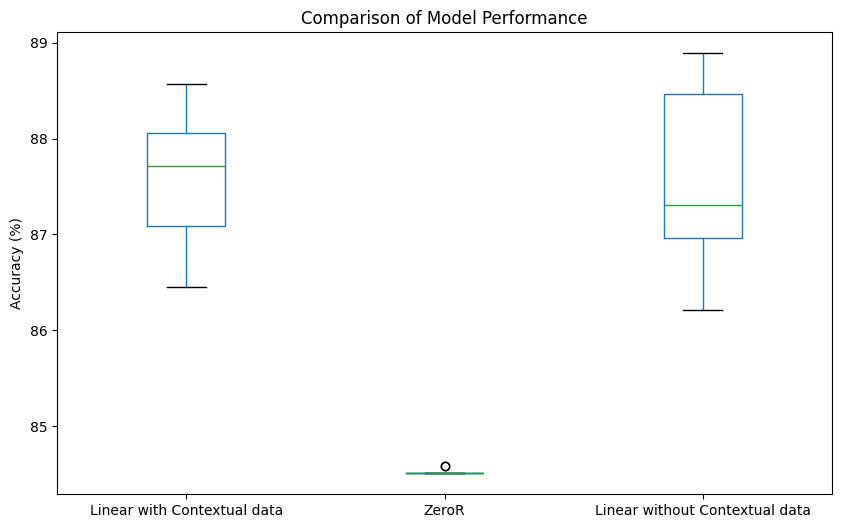

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


data_list = [results[0][0], results[1][0], results[2][0]]

data_to_plot = np.array(data_list).T

bp_df = pd.DataFrame(data_to_plot,columns=['Linear with Contextual data', 'ZeroR', 'Linear without Contextual data'])


plt.figure(figsize=(10, 6))
boxplot = bp_df.boxplot(column=['Linear with Contextual data', 'ZeroR', 'Linear without Contextual data'],grid=False )

plt.title('Comparison of Model Performance')
plt.ylabel('Accuracy (%)')
plt.show()


<h4> From this boxplot, we can see that the linear models hover around 87/88% accuracy and the ZeroR model stays at ~84% accuracy.
<br>Due to how similar the linear model's performances are, they will most likely not be statistically different, but we will perform a t-test to check for statistical differences between the linear models and ZeroR.

In [ ]:
from scipy import stats
ttest,pval = stats.ttest_rel(LR1_results[0], ZR_results[0])
if(pval>0.05):
  print("No, there is no statistical difference between Linear Model 1(has contextual data) and ZeroR")
else:
  print("Yes, there is a statistical difference between Linear Model 1(has contextual data) and ZeroR")

ttest,pval = stats.ttest_rel(LR2_results[0], ZR_results[0])
if(pval>0.05):
  print("No, there is no statistical difference between Linear Model 2(no contextual data) and ZeroR")
else:
  print("Yes, there is a statistical difference between Linear Model 2(no contextual data) and ZeroR")

ttest,pval = stats.ttest_rel(LR1_results[0], LR2_results[0])
if(pval>0.05):
  print("No, there is no statistical difference between Linear Model 2(no contextual data) and Linear Model 1(has contextual data)")
else:
  print("Yes, there is a statistical difference between Linear Model 2(no contextual data) and Linear Model 1(has contextual data)")

Yes, there is a statistical difference between Linear Model 1(has contextual data) and ZeroR
Yes, there is a statistical difference between Linear Model 2(no contextual data) and ZeroR
No, there is no statistical difference between Linear Model 2(no contextual data) and Linear Model 1(has contextual data)


<h4>From this we know two things. One, we know that our Linear models are worth it to use because they are able to outperform a baseline algorithm. Two, because there is no statistical difference between the two Linear models, neither outperform one another. Thus we know that contextual data does not make a difference in prediction accuracy.

<h2> 7. Conlusions </h2>
<h4>Key Findings <br>
1. Redundancy of Contextual Data <br>
As seen in the model performance and t-test, we know that the contextual data used in linear models are irrelevant. From the t-test output, we see that there is no statistical difference between the two linear models. The model with the contextual data performs the same as the model without, but due to Occam's razor, we know that the simplest model is best. Thus that means that for linear models, not using the contextual data leads to higher efficiency and less model dimensionality. Additionally, this leads to the need for less overhead work for data collection. <br>
2. Model Performance Versus Baseline
<br> From the t-test and the boxplot, we can see that the linear models outperform the baseline, so if one was to use a prediction task on this data, they can see that a linear model would be a good choice as it can statistically outpeform a baseline algorithm. Due to the imbalance in this dataset, the zeroR baseline can perform very well, but the linear models perform better. <br>
3. Contextual Feature Insights <br>
From our experiments with contextual feature analysis, we have some key insights into the most important contextual features. The most important one of these is the revenue correlation in November. In November, due to shopping sale opportunities like that of Black Friday or Cyber Monday, there is an increase in revenue among online shopping sites. Additionally, we found a difference between new visitors and returning visitors on shopping platforms, that shows that new visitors are more likely to result in revenue than returning visitors. While this could just be a fluke having to do with the lower amount of positive revenue instances within the data, it is still an interesting insight at this point. However, there were also plenty of uninteresting contextual datapoints, those being browser, OS, region, weekends, special days, and the majority of the months. These show that a lot of contextual data is not helpful in predicting revenue on online shopping platforms
<br> Practical Implications <br>
From our study, we can say that in these scenarios (i.e. predicting online shopper intention) it is most likely not valuable to give importance to contextual elements within the data. While it may be nice to have context on user information, it is not helpful for prediction and can decrease ML model efficiency.
